In [9]:
pip install anthropic

Note: you may need to restart the kernel to use updated packages.


In [10]:
import time
import anthropic
import matplotlib.pyplot as plt
import pandas as pd
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()
api_key = user_secrets.get_secret("Tropic")

client = anthropic.Anthropic(api_key=api_key)

# Pricing per million tokens (input / output)
PRICING = {
    "claude-opus-5": (5.00, 25.00),
    "claude-sonnet-5": (2.00, 10.00),
    "claude-haiku-4-5-20251001": (1.00, 5.00),
    "claude-fable-5-1": (10.00, 50.00),
}

def get_text(response):
    """Extract and concatenate all text blocks, skipping thinking/other blocks."""
    return "".join(
        block.text for block in response.content if block.type == "text"
    )

def calculate_cost(model, input_tokens, output_tokens):
    """Calculate cost in USD for a given model and token counts."""
    input_price, output_price = PRICING.get(model, (0, 0))
    # Prices are per million tokens, so divide by 1,000,000
    cost = (input_tokens * input_price / 1_000_000) + (output_tokens * output_price / 1_000_000)
    return cost

def compare_model_speeds():
    models = [
        "claude-opus-5",
        "claude-sonnet-5",
        "claude-haiku-4-5-20251001",
        "claude-fable-5-1",
    ]
    
    # Use your complex task here
    complex_task = """
    You are optimizing a delivery routing system. Given the following constraints, write a Python function 
    that solves this problem:

    - 8 delivery locations with (x, y) coordinates: 
      A(2,3), B(5,8), C(9,1), D(1,7), E(6,4), F(8,9), G(3,2), H(7,6)
    - A single delivery truck starts and ends at depot (0,0)
    - The truck has a maximum capacity of 5 stops per trip before returning to depot to reload
    - Minimize total distance traveled across all trips (Euclidean distance)

    Write a Python function `plan_routes(locations, capacity)` that:
    1. Groups locations into trips respecting the capacity constraint
    2. Orders stops within each trip to minimize distance (approximate is fine, e.g. nearest neighbor)
    3. Returns the full route plan and total distance
    4. Include a brief explanation of your algorithmic approach and its time complexity

    Then critique your own solution: what's the biggest weakness of this approach, and how would you 
    improve it for 1000+ locations?
    """

    results = []

    for model in models:
        start_time = time.time()

        response = client.messages.create(
            model=model,
            max_tokens=5000,
            messages=[{"role": "user", "content": complex_task}]
        )

        execution_time = time.time() - start_time
        input_tokens = response.usage.input_tokens
        output_tokens = response.usage.output_tokens
        total_tokens = input_tokens + output_tokens
        time_per_token = execution_time / total_tokens if total_tokens else 0
        cost = calculate_cost(model, input_tokens, output_tokens)

        print(f"Model: {model}")
        print(f"Response: {get_text(response)[:8000]}...")  # First 2000 chars
        print(f"Input Tokens: {input_tokens} | Output Tokens: {output_tokens}")
        print(f"Execution Time: {execution_time:.2f} seconds")
        print(f"Time Per Token: {time_per_token:.5f} seconds")
        print(f"Cost: ${cost:.4f}\n")

        results.append({
            "model": model,
            "input_tokens": input_tokens,
            "output_tokens": output_tokens,
            "execution_time": execution_time,
            "time_per_token": time_per_token,
            "cost_usd": cost,
        })

    return pd.DataFrame(results)

df = compare_model_speeds()
df

Model: claude-opus-5
Response: ...
Input Tokens: 372 | Output Tokens: 5000
Execution Time: 59.30 seconds
Time Per Token: 0.01104 seconds
Cost: $0.1269

Model: claude-sonnet-5
Response: # Delivery Route Planning Solution

## Implementation

```python
import math

def plan_routes(locations, capacity):
    """
    Plan delivery routes for a single truck with a per-trip capacity constraint.
    
    Algorithm:
    1. CLUSTERING (Sweep Algorithm): Sort all locations by polar angle 
       relative to the depot. This groups geographically adjacent points 
       together (since points at similar angles from origin tend to be 
       spatially close), then slice into chunks of size <= capacity.
    2. ROUTE ORDERING (Nearest Neighbor): Within each trip, greedily 
       visit the closest unvisited location.
    3. Compute total round-trip Euclidean distance across all trips.
    
    Time Complexity:
      - Sorting by angle: O(n log n)
      - Nearest-neighbor per trip: O(k^2), summed across

,model,input_tokens,output_tokens,execution_time,time_per_token,cost_usd
0,claude-opus-5,372,5000,59.304289,0.011040,0.126860
1,claude-sonnet-5,374,5000,41.484299,0.007719,0.050748
2,claude-haiku-4-5-20251001,280,2112,18.140155,0.007584,0.010840
3,claude-fable-5-1,374,5000,58.531341,0.010892,0.253740


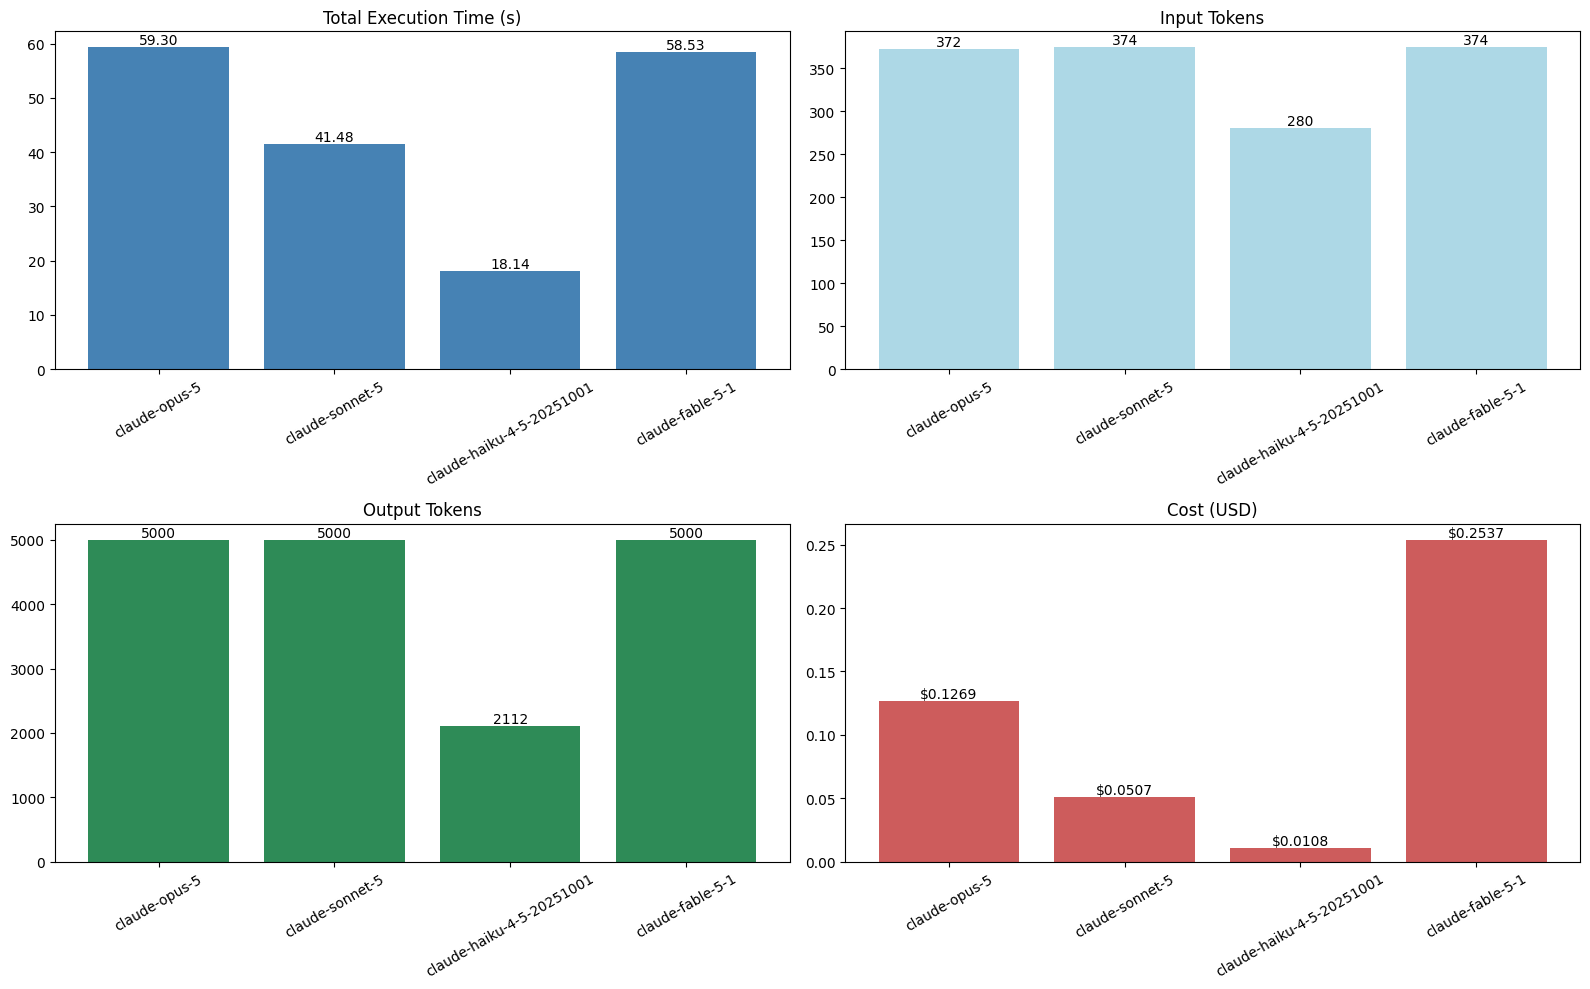

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Execution time
bars0 = axes[0, 0].bar(df["model"], df["execution_time"], color="steelblue")
axes[0, 0].set_title("Total Execution Time (s)")
axes[0, 0].tick_params(axis='x', rotation=30)
axes[0, 0].bar_label(bars0, fmt="%.2f")

# Input tokens
bars1 = axes[0, 1].bar(df["model"], df["input_tokens"], color="lightblue")
axes[0, 1].set_title("Input Tokens")
axes[0, 1].tick_params(axis='x', rotation=30)
axes[0, 1].bar_label(bars1, fmt="%d")

# Output tokens
bars2 = axes[1, 0].bar(df["model"], df["output_tokens"], color="seagreen")
axes[1, 0].set_title("Output Tokens")
axes[1, 0].tick_params(axis='x', rotation=30)
axes[1, 0].bar_label(bars2, fmt="%d")

# Cost
bars3 = axes[1, 1].bar(df["model"], df["cost_usd"], color="indianred")
axes[1, 1].set_title("Cost (USD)")
axes[1, 1].tick_params(axis='x', rotation=30)
axes[1, 1].bar_label(bars3, fmt="$%.4f")

plt.tight_layout()
plt.show()